# Tugas Besar Digital Signal Processing

Dinda Joycehana

122140048

#### Setup Library

In [1]:
## Import semua dependency yang diperlukan
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.signal as signal

In [2]:
#Download model melalui github informatika itera

## Create faceDetector Object
## Define the models
base_model="models/blaze_face_short_range.tflite"
base_options = python.BaseOptions(model_asset_path=base_model)

## Mediapipe configuration options
FaceDetectorOptions = vision.FaceDetectorOptions
VisionRunningMode = vision.RunningMode
options = FaceDetectorOptions(
    base_options=base_options,
    running_mode = VisionRunningMode.IMAGE,
)
face_detector = vision.FaceDetector.create_from_options(options)

#### POS (Plane-Orthogonal to Skin)

Metode rPPG mengambil sinyal denyut dari tubuh berdasarkan analisis perubahan warna yang dipancarkan kulit, yang kemudian diubah menjadi sinyal fisiologis.

In [ ]:
#Membuat fungsi POS
def POS(signal, **kargs):
    eps = 10**-9
    X = signal
    e, c, f = X.shape # Nilai dari estimator, channel (RGB), dan frame
    w = int(1.6 * kargs['fps']) # Window length in frames

    #P: Matriks transformasi warna dari RGB ke proyeksi POS
    #Q: Matriks p akan diklon berulang sebanyak e kali 
   
    P = np.array([[0, 1, -1], [-2, 1, 1]])
    Q = np.stack([P for _ in range(e)], axis = 0)

    ## H: Matriks keluaran yang akan menyimpan hasil dari setiap frame
    H = np.zeros((e, f))
    for n in np.arange(w, f): #looping sliding window
        m = n - w + 1

        #Normalisasi sinyal dari pengaruh cahaya
        Cn = X[:, :, m:(n+1)]
        M = 1.0 / (np.mean(Cn, axis = 2) + eps)
        M = np.expand_dims(M, axis=2) # shape [e, c, w]
        Cn = np.multiply(Cn, M)

       #proyeksikan sinyal RGB ke dalam domain POS
        S = np.dot(Q, Cn)
        S = S[0, :, :, :]
        S = np.swapaxes(S, 0, 1) 

       #Tuning sinyal
        S1 = S[:, 0, :]
        S2 = S[:, 1, :]
        alpha = np.std(S1, axis=1) / (eps + np.std(S2, axis=1))
        alpha - np.expand_dims(alpha, axis=1)
        Hn = np.add(S1, alpha * S2)
        Hnm = Hn - np.expand_dims(np.mean(Hn, axis=1), axis=1)

        #Overlap-add
        H[:, m:(n + 1)] = np.add(H[:, m:(n + 1)], Hnm)  # Add the tuned signal to the output matrix

    return H

In [ ]:
#inisiallisasi variabel untuk sinyal fisioligis
r_signal, g_signal, b_signal = [], [], [] #menyimpan nilai R, G, dan B dari kulit wajah
fps = 15 # atur frame rate sesuai dengan kualitas webcam 
time_window = 60 #Panjang durasi video yang dianalisis
frame_buffer_limit = time_window * fps #Jumlah maksimal frame
frame_buffer = [] #simpan nilai frame buffer
margin_x = 10 # beri padding secara horizontal
scaling_factor = 0.8 # mengatur ukuran bounding boz

In [3]:
# Inisialisasi MediaPipe Face Detection
mp_face_detection = mp.solutions.face_detection

# Fungsi untuk mendeteksi wajah dari webcam
def detect_faces_from_webcam():
    # Membuka webcam
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Webcam tidak tersedia.")
        return


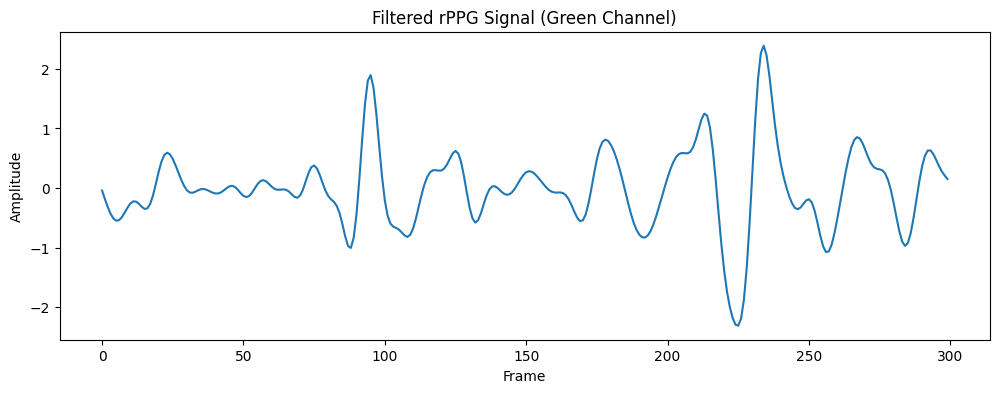

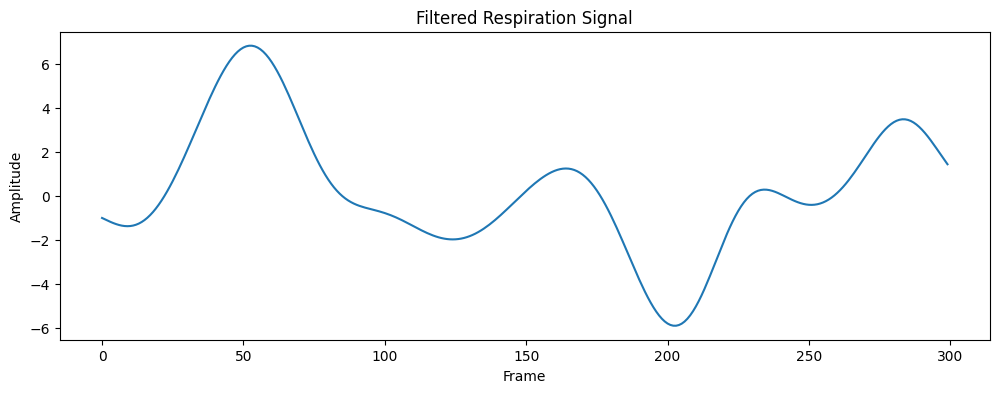

In [6]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
from scipy.signal import detrend, butter, filtfilt

# Helper functions
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

# Initialize MediaPipe
mp_face = mp.solutions.face_detection
face_detection = mp_face.FaceDetection(model_selection=0, min_detection_confidence=0.7)

cap = cv2.VideoCapture(0)
fps = cap.get(cv2.CAP_PROP_FPS) or 30

rppg_signals = []
resp_signals = []
frames = 300  # Number of frames to capture (~10s at 30fps)
count = 0

while count < frames:
    ret, frame = cap.read()
    if not ret:
        break
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_detection.process(rgb)
    h, w, _ = frame.shape

    if results.detections:
        for detection in results.detections:
            bbox = detection.location_data.relative_bounding_box
            x1 = int(bbox.xmin * w)
            y1 = int(bbox.ymin * h)
            x2 = int((bbox.xmin + bbox.width) * w)
            y2 = int((bbox.ymin + bbox.height) * h)

            # rPPG ROI: forehead
            fh = int((y2 - y1) * 0.2)
            roi_rppg = frame[y1:y1+fh, x1:x2]
            if roi_rppg.size > 0:
                mean_rgb = np.mean(np.mean(roi_rppg, axis=0), axis=0)
                rppg_signals.append(mean_rgb)

            # Respiration ROI: chest (below face)
            chest_y1 = y2 + int(0.05 * h)
            chest_y2 = chest_y1 + int(0.15 * h)
            chest_x1 = x1
            chest_x2 = x2
            roi_resp = frame[chest_y1:chest_y2, chest_x1:chest_x2]
            if roi_resp.size > 0:
                mean_intensity = np.mean(cv2.cvtColor(roi_resp, cv2.COLOR_BGR2GRAY))
                resp_signals.append(mean_intensity)

            # Draw rectangles for visualization
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.rectangle(frame, (chest_x1, chest_y1), (chest_x2, chest_y2), (255,0,0), 2)
            break  # Only process first face

    cv2.imshow('Webcam', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    count += 1

cap.release()
cv2.destroyAllWindows()

# Convert to numpy arrays
rppg_signals = np.array(rppg_signals)
resp_signals = np.array(resp_signals)

# Process rPPG (heart rate)
if len(rppg_signals) > 0:
    green = detrend(rppg_signals[:,1])
    filtered = bandpass_filter(green, 0.7, 3, fps, order=3)  # 42-180 bpm
    plt.figure(figsize=(12,4))
    plt.plot(filtered)
    plt.title('Filtered rPPG Signal (Green Channel)')
    plt.xlabel('Frame')
    plt.ylabel('Amplitude')
    plt.show()

# Process Respiration
if len(resp_signals) > 0:
    resp_filtered = bandpass_filter(detrend(resp_signals), 0.1, 0.7, fps, order=3)  # 6-42 bpm
    plt.figure(figsize=(12,4))
    plt.plot(resp_filtered)
    plt.title('Filtered Respiration Signal')
    plt.xlabel('Frame')
    plt.ylabel('Amplitude')
    plt.show()